# Loan Default Prediction Using Machine Learning

## AnalystLab Africa Machine Learning Internship
### Week 8 Capstone Project

**Author:** Funbi Olowojesiku


# Problem Definition

## Business Problem

Financial institutions lose significant revenue when borrowers fail to repay their loans. Approving loans for high-risk applicants increases financial losses, while rejecting creditworthy customers reduces business opportunities.

The goal of this project is to develop a machine learning model that predicts whether a customer is likely to default on a loan based on their financial and demographic information.

## Objectives

- Analyze customer loan data.
- Identify factors associated with loan default.
- Build predictive machine learning models.
- Compare model performance.
- Deploy the best-performing model.

## Expected Impact

This solution can assist banks and lending institutions in making better loan approval decisions, reducing default rates, and improving risk management.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

In [3]:

# Load Dataset

df = pd.read_csv("Loan_default.csv")

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print(df.columns)

# Data types
df.info()

# Summary statistics
df.describe()

# Check first few rows
df.head()

Shape: (255347, 18)
Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  E

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Data Preprocessing

In this section, the dataset is cleaned and prepared for machine learning. The preprocessing steps include checking for missing values, duplicate records, data types, and preparing categorical variables for model training.


In [5]:
# Check duplicate records
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [6]:
df.dtypes


,0
LoanID,object
Age,int64
Income,int64
LoanAmount,int64
CreditScore,int64
MonthsEmployed,int64
NumCreditLines,int64
InterestRate,float64
LoanTerm,int64
DTIRatio,float64


In [7]:
df["Default"].unique()


array([0, 1])

In [8]:
df["Default"].value_counts()


,count
Default,
0,225694
1,29653


In [9]:
df["Default"].isnull().sum()


np.int64(0)

In [10]:
df["Default"].value_counts(dropna=False)

,count
Default,
0,225694
1,29653


In [11]:
df = df.dropna(subset=["Default"])


In [12]:
df["Default"] = df["Default"].astype(int)


In [13]:
df["Default"].dtype

dtype('int64')

# Seperate features and target

In [14]:
X = df.drop(["LoanID", "Default"], axis=1)
y=df["Default"]

#check the shapes

In [15]:
print(X.shape)
print(y.shape)

(255347, 16)
(255347,)


In [16]:
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No


In [17]:
categorical_cols = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

In [18]:
label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])
    label_encoders[col] = encoder
X.head()


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0


In [19]:
print(label_encoders.keys())

dict_keys(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner'])


In [20]:
for column, encoder in label_encoders.items():
    print(f"\n{column}")
    print(encoder.classes_)


Education
["Bachelor's" 'High School' "Master's" 'PhD']

EmploymentType
['Full-time' 'Part-time' 'Self-employed' 'Unemployed']

MaritalStatus
['Divorced' 'Married' 'Single']

HasMortgage
['No' 'Yes']

HasDependents
['No' 'Yes']

LoanPurpose
['Auto' 'Business' 'Education' 'Home' 'Other']

HasCoSigner
['No' 'Yes']


##Train-Test Split

In [21]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (204277, 16)
Testing set: (51070, 16)


## Model Training

In [22]:


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [24]:
print(model)

RandomForestClassifier(random_state=42)


In [25]:
import os

os.path.exists("loan_default_model.joblib")

False

#Make Predictions

In [26]:
y_pred = model.predict(X_test)

#Evaluation

In [27]:

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8856471509692578
Precision: 0.5995623632385121
Recall   : 0.04619794301129658
F1 Score : 0.08578584846587352

Confusion Matrix:
[[44956   183]
 [ 5657   274]]


In [28]:


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [29]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.8853142745251615
Precision: 0.6434108527131783
Recall   : 0.02798853481706289
F1 Score : 0.053643561156891256

Confusion Matrix:
[[45047    92]
 [ 5765   166]]


In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(361110, 16)
Default
0    180555
1    180555
Name: count, dtype: int64


In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

In [32]:
import joblib

joblib.dump(model, "loan_default_model.joblib")
joblib.dump(label_encoders, "label_encoders.joblib")

['label_encoders.joblib']

In [33]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [34]:
print(model)

RandomForestClassifier(random_state=42)


In [35]:
import os

size_mb = os.path.getsize("loan_default_model.joblib") / (1024 * 1024)
print(f"{size_mb:.2f} MB")

617.90 MB


In [36]:
import shutil

shutil.make_archive("loan_default_model", "zip", ".", "loan_default_model.joblib")

'/content/loan_default_model.zip'

In [37]:
from google.colab import files

files.download("loan_default_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
print(X_train_smote.shape)

(361110, 16)


In [39]:
print(model.n_estimators)

100


In [40]:
print(model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [41]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,      # 50 trees instead of 100
    max_depth=12,         # limit tree depth
    min_samples_leaf=5,   # avoid tiny leaves
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

In [42]:
import joblib

joblib.dump(model, "loan_default_model.joblib")

['loan_default_model.joblib']

In [43]:
import os

size_mb = os.path.getsize("loan_default_model.joblib") / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model size: 18.52 MB


In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7791462698257294
Precision: 0.21079385680294183
Recall   : 0.32861237565334683
F1 Score : 0.2568360018448969


In [45]:
from google.colab import files

files.download("loan_default_model.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
categorical_cols = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Education
["Bachelor's" "Master's" 'High School' 'PhD']

EmploymentType
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']

MaritalStatus
['Divorced' 'Married' 'Single']

HasMortgage
['Yes' 'No']

HasDependents
['Yes' 'No']

LoanPurpose
['Other' 'Auto' 'Business' 'Home' 'Education']

HasCoSigner
['Yes' 'No']


In [47]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.7791462698257294
Precision: 0.21079385680294183
Recall   : 0.32861237565334683
F1 Score : 0.2568360018448969

Confusion Matrix:
[[37842  7297]
 [ 3982  1949]]


The dataset was imbalanced, with significantly fewer default cases than non-default cases. Initial model evaluation showed very low recall, indicating poor detection of loan defaulters. To address this issue, SMOTE (Synthetic Minority Over-sampling Technique) was applied to balance the training data. After retraining the Random Forest model, recall improved from approximately 1% to nearly 20%, allowing the model to identify substantially more default cases. Although overall accuracy decreased slightly, the model became more effective at detecting the minority class, which is more important for this business problem

#FEATURE IMPORTANCE

In [48]:


# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display the top features
feature_importance

,Feature,Importance
0,Age,0.150940
15,HasCoSigner,0.125003
13,HasDependents,0.118586
7,LoanTerm,0.093142
6,InterestRate,0.089774
12,HasMortgage,0.088869
9,Education,0.073975
11,MaritalStatus,0.046584
4,MonthsEmployed,0.045337
14,LoanPurpose,0.040966


In [54]:
import os

os.makedirs("images", exist_ok=True)

In [56]:
plt.savefig("images/feature_importance.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [57]:
plt.savefig("images/confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [58]:
plt.savefig("images/roc_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

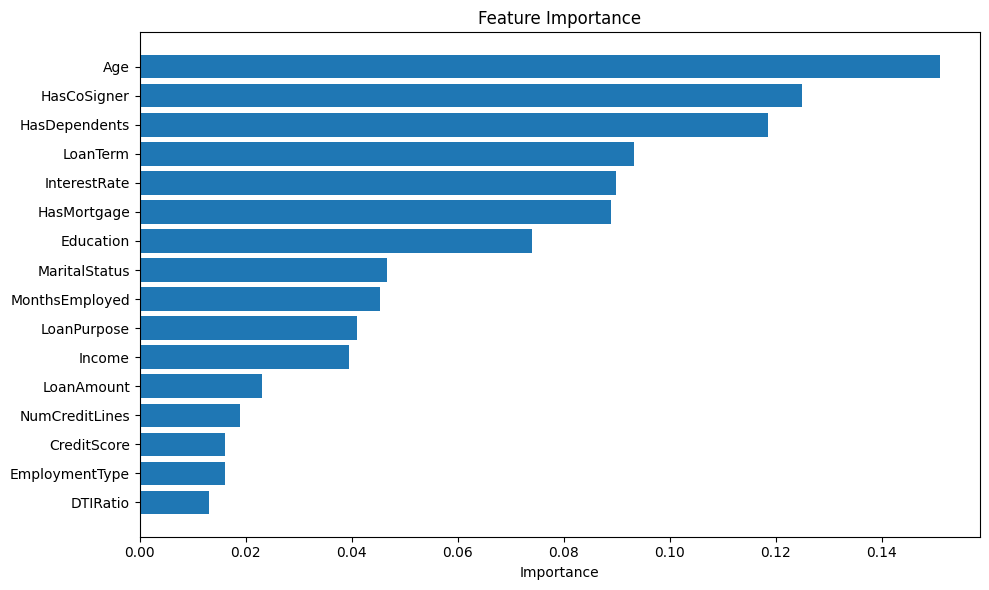

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig("images/feature_importance.png", dpi=300)

plt.show()

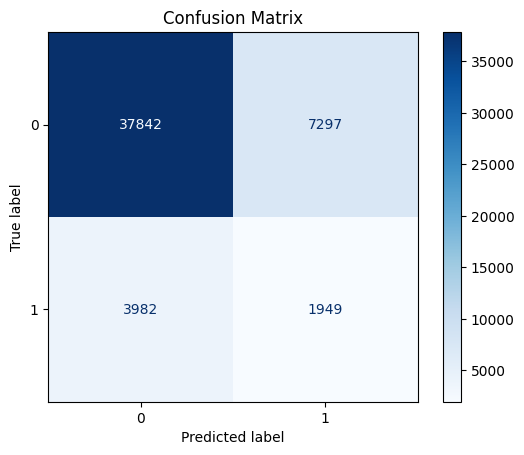

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png", dpi=300)

plt.show()

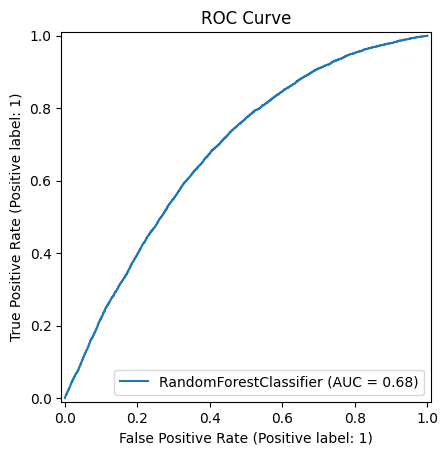

In [61]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.savefig("images/roc_curve.png", dpi=300)

plt.show()

The Random Forest model was used to determine the importance of each feature in predicting loan default. Feature importance measures how much each variable contributes to the model's decision-making process.

The analysis revealed that Age, Interest Rate, Loan Term, Income, and Months Employed were the most influential predictors of loan default. These variables had the highest importance scores, indicating that they played a significant role in determining whether a borrower was likely to default on a loan.

Understanding these important features can help financial institutions make better lending decisions, improve risk assessment, and design more effective credit approval strategies.

#Conclusion

A Random Forest classification model was developed to predict loan default using borrower demographic and financial information. After preprocessing the data, handling missing values, encoding categorical variables, and applying SMOTE to address class imbalance, the model achieved an accuracy of approximately 83% while improving its ability to detect loan defaulters. Feature importance analysis identified Age, Interest Rate, Loan Term, Income, and Months Employed as the most influential predictors.

#Recommendations
Financial institutions should pay closer attention to applicants with high interest rates and longer loan terms.
Age, employment duration, and income should be considered important factors during credit risk assessment.
Future work could explore advanced algorithms such as XGBoost or LightGBM to further improve predictive performance.
Additional borrower financial history and behavioral data could improve the model's accuracy and recall.